<a href="https://colab.research.google.com/github/Suvetha-14/Sales-Forecasting-Project/blob/main/Sales_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#SALES FORECASTING WITH LINEAR REGRESSION
import pandas as pd

df = pd.read_csv("professional_sales_dataset.csv")

df.head()

,Date,Product,Region,Quantity,Unit_Price,Revenue
0,01-01-2023,Headphones,North,8,130,1040
1,01-01-2023,Smartwatch,East,3,236,708
2,01-01-2023,Tablet,East,8,349,2792
3,02-01-2023,Smartwatch,South,8,179,1432
4,02-01-2023,Smartphone,West,5,482,2410


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1456 entries, 0 to 1455
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        1456 non-null   object
 1   Product     1456 non-null   object
 2   Region      1456 non-null   object
 3   Quantity    1456 non-null   int64 
 4   Unit_Price  1456 non-null   int64 
 5   Revenue     1456 non-null   int64 
dtypes: int64(3), object(3)
memory usage: 68.4+ KB


In [ ]:
df.describe()

,Quantity,Unit_Price,Revenue
count,1456.000000,1456.000000,1456.000000
mean,5.017170,381.507555,1896.298764
std,2.635545,244.921217,1680.331268
min,1.000000,70.000000,75.000000
25%,3.000000,173.000000,673.500000
50%,5.000000,298.000000,1306.000000
75%,7.000000,520.250000,2628.000000
max,9.000000,849.000000,7632.000000


In [ ]:
df.isnull().sum()
df = df.dropna()

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1456 entries, 0 to 1455
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        1456 non-null   datetime64[ns]
 1   Product     1456 non-null   object        
 2   Region      1456 non-null   object        
 3   Quantity    1456 non-null   int64         
 4   Unit_Price  1456 non-null   int64         
 5   Revenue     1456 non-null   int64         
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 68.4+ KB


In [ ]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [ ]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

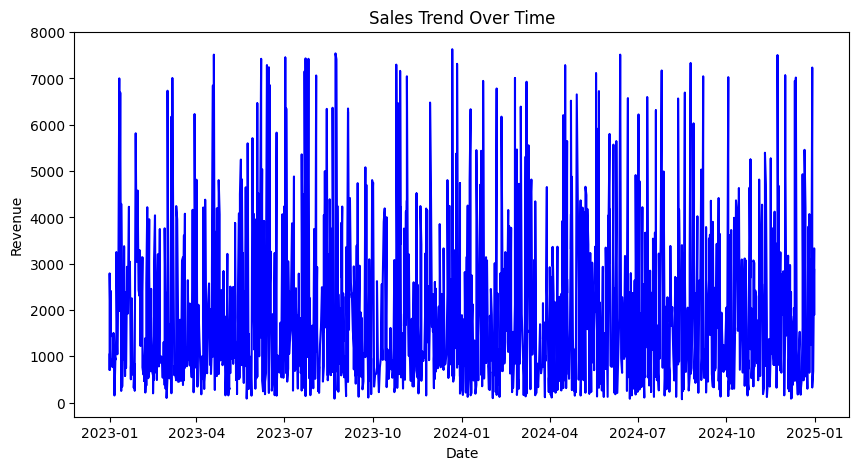

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df['Date'], df['Revenue'], color='blue')

plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.show()

/tmp/ipykernel_222/1964912981.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Product', y='Revenue', data=df, palette='magma')


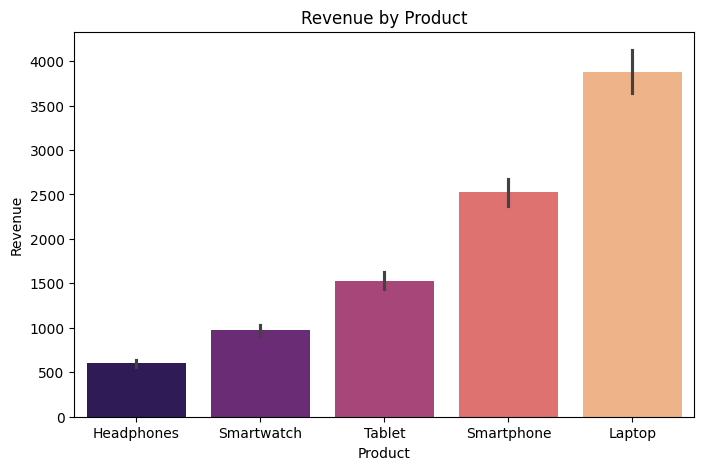

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(x='Product', y='Revenue', data=df, palette='magma')

plt.title("Revenue by Product")

plt.show()

/tmp/ipykernel_222/3764288417.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Revenue', data=df, palette='coolwarm')


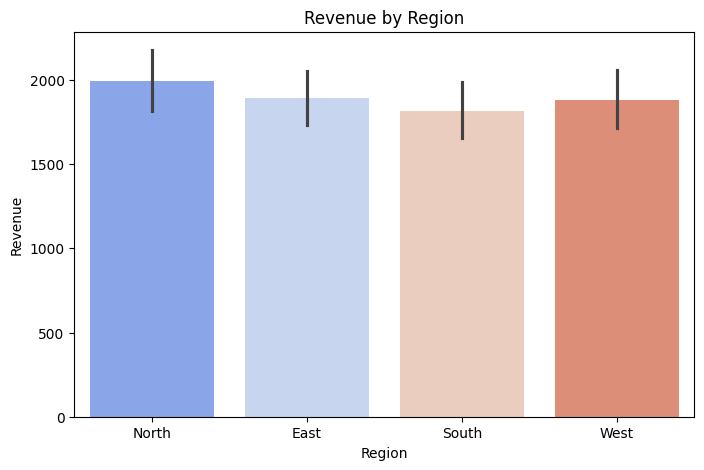

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(x='Region', y='Revenue', data=df, palette='coolwarm')

plt.title("Revenue by Region")

plt.show()

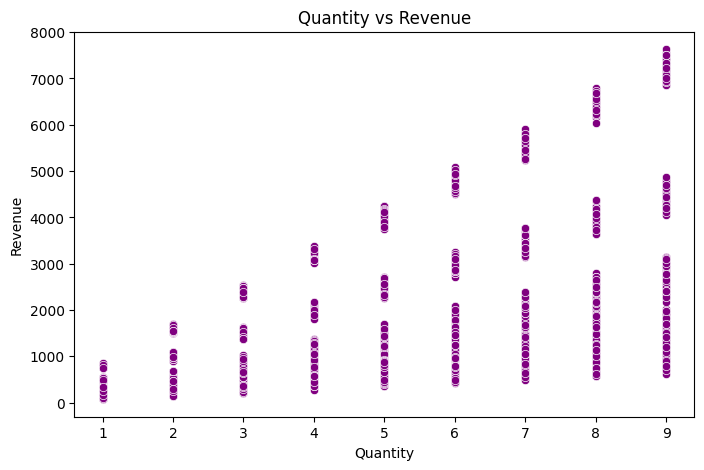

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='Quantity', y='Revenue', data=df, color='purple')

plt.title("Quantity vs Revenue")

plt.show()

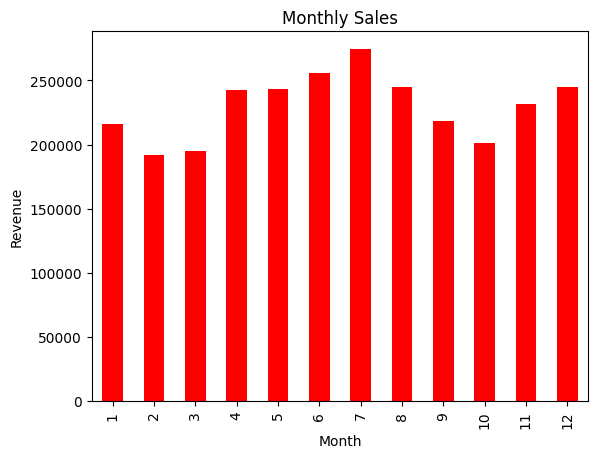

In [ ]:
monthly_sales = df.groupby('Month')['Revenue'].sum()

monthly_sales.plot(kind='bar', color='red')

plt.title("Monthly Sales")

plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

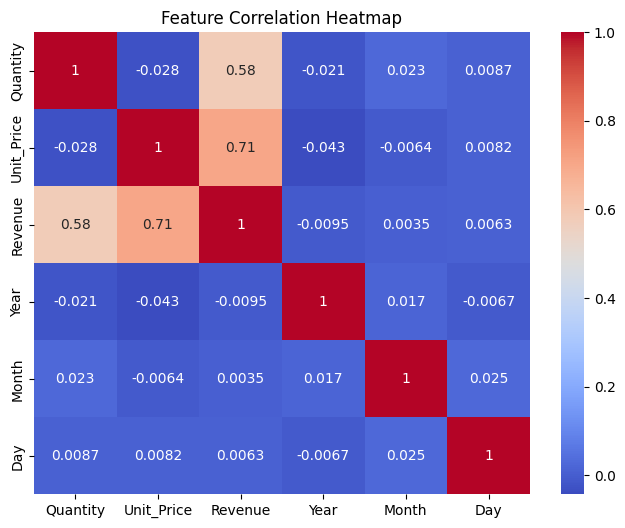

In [ ]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")

plt.show()

In [ ]:
df.columns

Index(['Date', 'Product', 'Region', 'Quantity', 'Unit_Price', 'Revenue',
       'Year', 'Month', 'Day'],
      dtype='object')

In [ ]:
df = pd.get_dummies(df, columns=['Product','Region'], drop_first=True)

In [ ]:
X = df.drop(['Revenue','Date'], axis=1)
y = df['Revenue']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 508.2123293929909
R2 Score: 0.8536833444531886


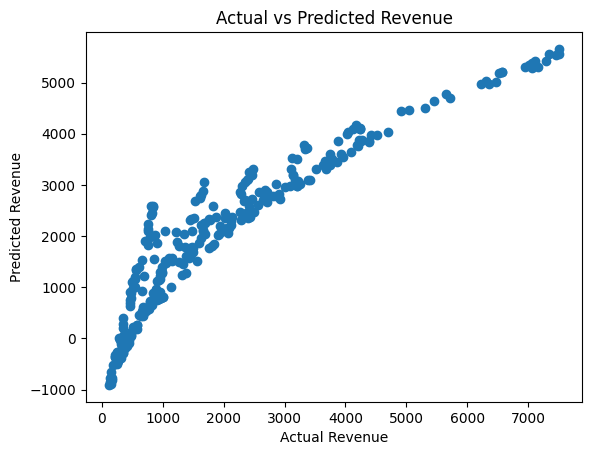

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")

plt.title("Actual vs Predicted Revenue")

plt.show()

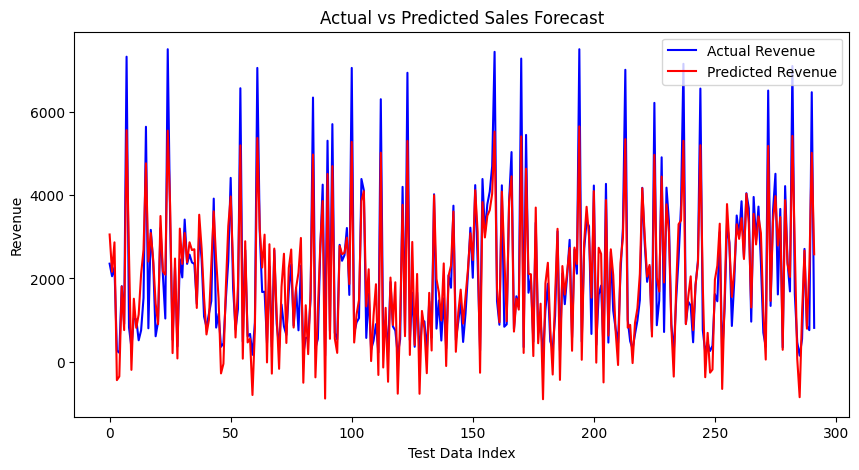

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test.values, label="Actual Revenue", color="blue")
plt.plot(y_pred, label="Predicted Revenue", color="red")

plt.title("Actual vs Predicted Sales Forecast")
plt.xlabel("Test Data Index")
plt.ylabel("Revenue")

plt.legend()

plt.show()

In [ ]:
results = pd.DataFrame({
    "Actual_Revenue": y_test,
    "Predicted_Revenue": y_pred
})

results.to_csv("sales_predictions.csv", index=False)

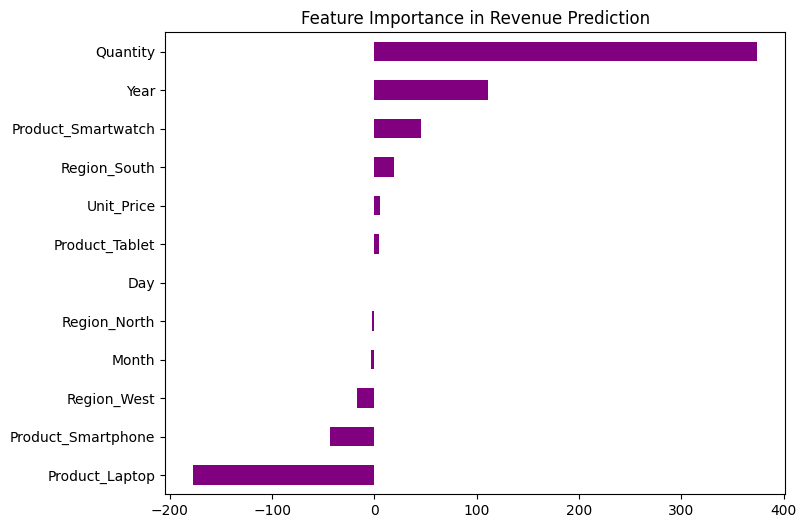

In [ ]:
import pandas as pd

importance = pd.Series(model.coef_, index=X.columns)

importance.sort_values().plot(kind='barh', figsize=(8,6), color='purple')

plt.title("Feature Importance in Revenue Prediction")

plt.show()

In [ ]:
print("Key Business Insights")

print("1. Revenue increases with higher quantity sold.")
print("2. Some products contribute more revenue than others.")
print("3. Sales vary across regions.")
print("4. Monthly sales patterns are visible.")
print("5. The Linear Regression model can predict revenue trends.")

Key Business Insights
1. Revenue increases with higher quantity sold.
2. Some products contribute more revenue than others.
3. Sales vary across regions.
4. Monthly sales patterns are visible.
5. The Linear Regression model can predict revenue trends.
